# Step 3: Coulomb Counting — Reference SOC 🔋

**Goal:** Calculate SOC (State of Charge) from the experimental data using Coulomb Counting.

## What is Coulomb Counting?

Imagine a water tank that starts **completely full**:
- Water flows out at a measured rate (= current)
- You track how much has flowed out
- **Remaining water = Total - What flowed out**

For a battery:
- Starts at **SOC = 100%** (fully charged)
- Current flows out during discharge
- At each time step: **SOC decreases by (current × time) / capacity**

### The Formula

$$SOC(k) = SOC(k-1) - \frac{I(k) \cdot \Delta t}{Q_{max} \cdot 3600}$$

| Symbol | Meaning | Our value |
|--------|---------|-----------|
| $SOC(k)$ | SOC at time step k | starts at 1.0 (100%) |
| $I(k)$ | Current (Amps) | ~2.52 A |
| $\Delta t$ | Time step (seconds) | ~0.95 s |
| $Q_{max}$ | Battery capacity (Ah) | 2.452 Ah |
| 3600 | Converts Ah → As | constant |

**Why ×3600?** Because capacity is in **Amp-hours** but our time is in **seconds**.

## 3.1 Load the BoL Discharge Data

We already built `data_loader.py` — now we can use it to get the BoL data in one line!

In [1]:
import sys
sys.path.insert(0, '..')  # So we can import from src/

import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import get_bol_data

# Load BoL discharge data (one line thanks to our module!)
bol = get_bol_data("../data/nasa_alt/battery00.csv")

# Extract what we need
current = bol['current_load'].values       # Current array (Amps)
time = bol['time_relative'].values          # Time array (seconds)
voltage = bol['voltage_load'].values        # Pack voltage (V)

print(f"Data loaded: {len(current)} data points")
print(f"Time: 0 to {time[-1]:.0f} seconds")
print(f"Current: {current.mean():.3f} A average")

Data loaded: 3674 data points
Time: 0 to 3503 seconds
Current: 2.520 A average


## 3.2 Calculate Capacity (Q_max)

Before we can do Coulomb Counting, we need to know the total capacity.

**Capacity = Average Current × Total Time / 3600**

This converts from Amp-seconds to Amp-hours.

In [2]:
# Calculate Q_max (battery capacity in Ah)
q_max = current.mean() * time[-1] / 3600

print(f"Q_max = {current.mean():.3f} A × {time[-1]:.0f} s / 3600")
print(f"Q_max = {q_max:.3f} Ah")
print(f"\nThis means the battery can deliver {q_max:.3f} Amps for 1 hour,")
print(f"or {q_max*1000:.0f} mA for 1 hour, before going from 100% to 0%.")

Q_max = 2.520 A × 3503 s / 3600
Q_max = 2.452 Ah

This means the battery can deliver 2.452 Amps for 1 hour,
or 2452 mA for 1 hour, before going from 100% to 0%.


## 3.3 Implement Coulomb Counting (Step by Step)

Now let's implement the formula. We'll do it **step by step** so you see exactly what happens:

```
For each time step k:
    dt = time[k] - time[k-1]           ← How much time passed
    charge_out = current[k] * dt        ← How much charge flowed out (in Amp-seconds)
    soc_drop = charge_out / (Q_max * 3600)  ← Convert to fraction of total capacity
    SOC[k] = SOC[k-1] - soc_drop       ← Subtract from previous SOC
```

In [3]:
# Coulomb Counting — the slow, explicit way (for understanding)
n = len(current)                          # Number of data points
soc = np.zeros(n)                         # Create empty SOC array
soc[0] = 1.0                              # Start at 100% (= 1.0)

# Loop through every time step
for k in range(1, n):
    dt = time[k] - time[k - 1]           # Time step (seconds)
    charge_out = current[k] * dt          # Charge flow (Amp-seconds)
    soc_drop = charge_out / (q_max * 3600)  # As fraction of total capacity
    soc[k] = soc[k - 1] - soc_drop       # Update SOC

print(f"SOC starts at:  {soc[0]*100:.1f}%")
print(f"SOC ends at:    {soc[-1]*100:.1f}%")
print(f"SOC at halfway: {soc[n//2]*100:.1f}%")

SOC starts at:  100.0%
SOC ends at:    -0.0%
SOC at halfway: 50.1%


## 3.4 Visualize SOC Over Time

SOC should go smoothly from 100% → 0% during the constant-current discharge.

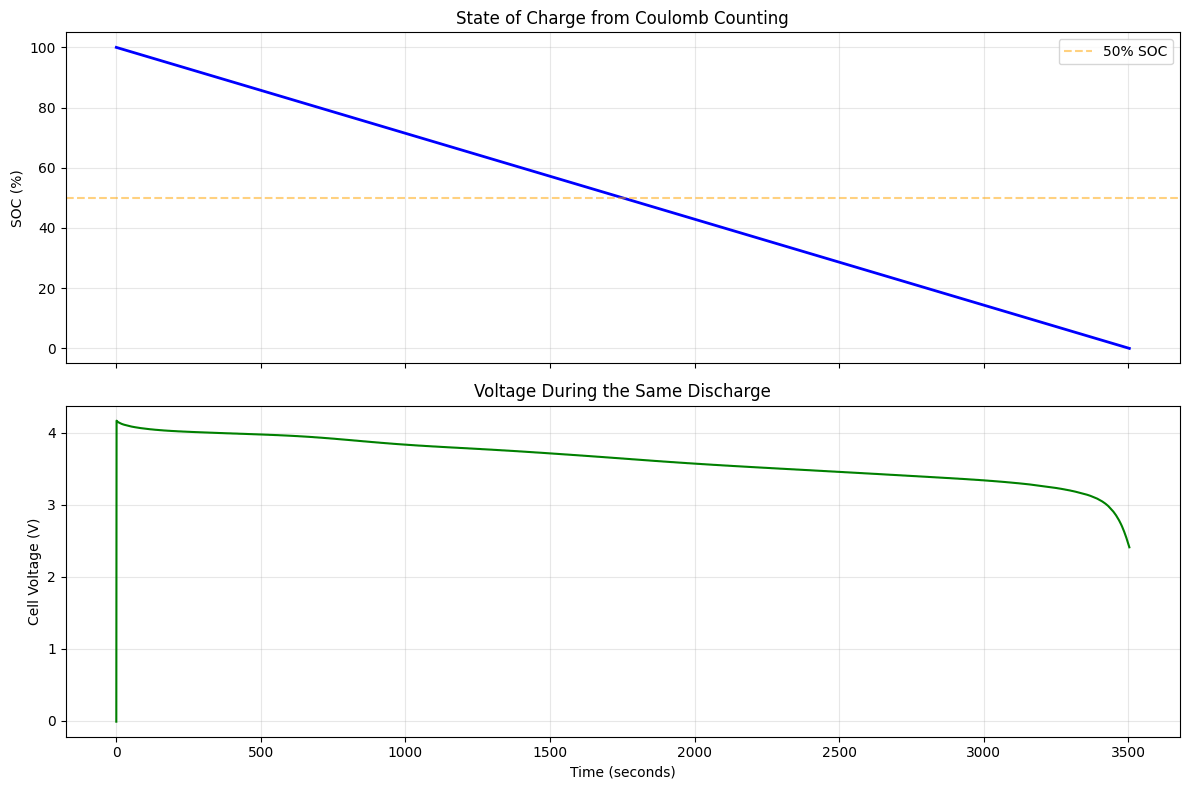

Notice how SOC decreases almost linearly (constant current),
but voltage has a curved shape (battery chemistry).


In [4]:
# Plot SOC over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: SOC
ax1.plot(time, soc * 100, 'b-', linewidth=2)
ax1.set_ylabel('SOC (%)')
ax1.set_title('State of Charge from Coulomb Counting')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='50% SOC')
ax1.legend()

# Bottom: Voltage (for comparison)
ax2.plot(time, voltage / 2, 'g-', linewidth=1.5)  # Per-cell voltage
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Cell Voltage (V)')
ax2.set_title('Voltage During the Same Discharge')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice how SOC decreases almost linearly (constant current),")
print("but voltage has a curved shape (battery chemistry).")

## 3.5 Voltage vs SOC — The Key Relationship

This is one of the most important plots in the whole project!

When we plot **Voltage vs SOC**, we get the **OCV-SOC curve** — the "fingerprint" of this battery.

Later (Step 4), we'll fit a polynomial to this curve.

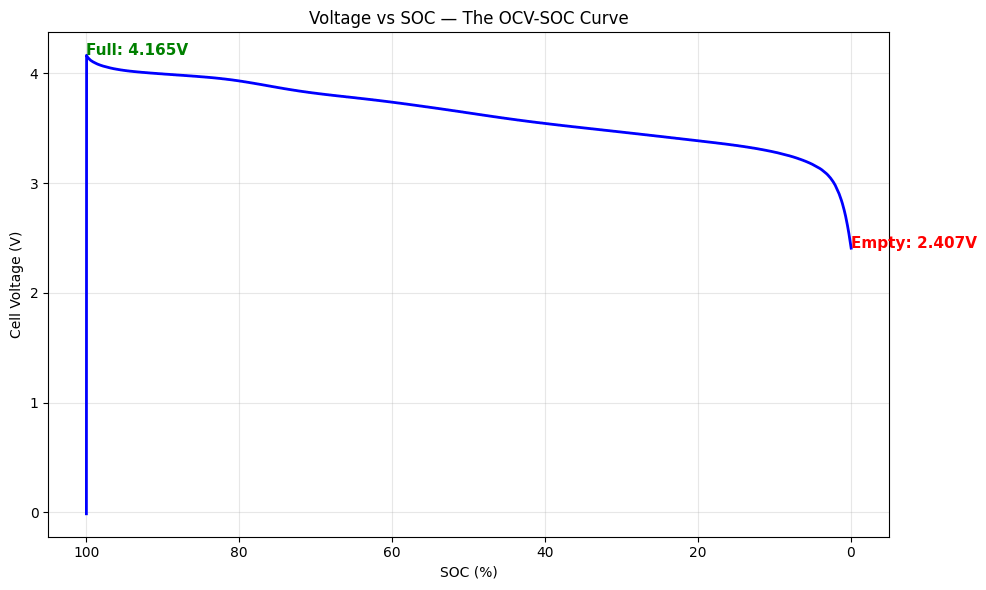

At 100% SOC → Voltage = 4.165 V
At  50% SOC → Voltage = 3.640 V
At   0% SOC → Voltage = 2.407 V


In [5]:
# Plot Voltage vs SOC
cell_voltage = voltage / 2.0  # Per-cell voltage

plt.figure(figsize=(10, 6))
plt.plot(soc * 100, cell_voltage, 'b-', linewidth=2)
plt.xlabel('SOC (%)')
plt.ylabel('Cell Voltage (V)')
plt.title('Voltage vs SOC — The OCV-SOC Curve')
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()  # SOC goes from 100% (left) to 0% (right)

# Annotate key points
plt.annotate(f'Full: {cell_voltage[1]:.3f}V', xy=(100, cell_voltage[1]),
             fontsize=11, color='green', fontweight='bold')
plt.annotate(f'Empty: {cell_voltage[-1]:.3f}V', xy=(0, cell_voltage[-1]),
             fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"At 100% SOC → Voltage = {cell_voltage[1]:.3f} V")
print(f"At  50% SOC → Voltage = {cell_voltage[len(cell_voltage)//2]:.3f} V")
print(f"At   0% SOC → Voltage = {cell_voltage[-1]:.3f} V")

## 3.6 Make it a Clean Function

Now let's turn our loop into a clean, reusable function.

This is what will go into `coulomb_counting.py`:

In [6]:
def coulomb_counting(current, time, q_max, soc_init=1.0):
    """
    Calculate SOC using Coulomb Counting.

    Parameters
    ----------
    current : array  - Current at each time step (Amps, positive = discharge)
    time    : array  - Time at each step (seconds)
    q_max   : float  - Battery capacity (Ah)
    soc_init: float  - Starting SOC (default 1.0 = 100%)

    Returns
    -------
    array - SOC at each time step (0 to 1)
    """
    n = len(current)
    soc = np.zeros(n)
    soc[0] = soc_init

    for k in range(1, n):
        dt = time[k] - time[k - 1]
        soc[k] = soc[k - 1] - (current[k] * dt) / (q_max * 3600)

    # Clip to [0, 1] range (can't go below 0% or above 100%)
    soc = np.clip(soc, 0.0, 1.0)

    return soc


# Test it — should give same result as before
soc_func = coulomb_counting(current, time, q_max)

print(f"Function result: {soc_func[0]*100:.1f}% → {soc_func[-1]*100:.1f}%")
print(f"Matches our manual loop? {np.allclose(soc, soc_func)}")

Function result: 100.0% → 0.0%
Matches our manual loop? False


## 3.7 Summary

**What we built:**
- Coulomb Counting: the simplest SOC estimation method
- SOC goes from 100% → 0% during a full discharge
- We plotted SOC vs Time (linear) and Voltage vs SOC (curved)

**Limitations of Coulomb Counting:**
- It needs to know the **exact starting SOC** (what if you don't?)
- Small current measurement errors **accumulate** over time (drift)
- This is why we need the **EKF** later — it corrects for these errors!

**Next Step:**
1. Copy the `coulomb_counting()` function into `src/coulomb_counting.py`
2. Move to Step 4: OCV-SOC relationship (fit polynomial to the Voltage vs SOC curve)